In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All libraries ready")

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
import subprocess
subprocess.run(['pip', 'install', 'matplotlib', 'seaborn', 'scikit-learn', 'pandas', 'numpy', 'joblib'], 
               capture_output=False)
print("Done")

Done


In [3]:
df = pd.read_csv('data/final_dataset_ready.csv')

FEATURES  = ['avg_attempts', 'avg_time_sec', 'engagement_score', 'difficulty']
LABELS    = ['Maintain', 'Promote', 'Demote']
label_map = {0: 'Maintain', 1: 'Promote', 2: 'Demote'}

print(f"Total rows    : {len(df):,}")
print(f"Total columns : {len(df.columns)}")
print(f"Null values   : {df.isnull().sum().sum()}")
print()
print("Label distribution:")
for i, n in df['recommendation'].value_counts().sort_index().items():
    print(f"  {label_map[i]:<10}: {n:,}  ({n/len(df)*100:.1f}%)")
print()
print("Source distribution:")
for src, n in df['source'].value_counts().items():
    print(f"  {src:<15}: {n:,}  ({n/len(df)*100:.1f}%)")
print()
df[FEATURES].describe().round(3)

Total rows    : 94,818
Total columns : 9
Null values   : 0

Label distribution:
  Maintain  : 30,381  (32.0%)
  Promote   : 43,990  (46.4%)
  Demote    : 20,447  (21.6%)

Source distribution:
  assistments    : 89,368  (94.3%)
  oulad          : 5,241  (5.5%)
  uci            : 209  (0.2%)



,avg_attempts,avg_time_sec,engagement_score,difficulty
count,94818.000,94818.000,94818.000,94818.000
mean,1.236,44.652,0.962,1.268
std,0.747,54.186,0.078,0.850
min,0.000,0.000,0.353,0.000
25%,1.000,14.884,0.966,0.000
50%,1.000,27.784,0.987,2.000
75%,1.400,55.725,0.998,2.000
max,10.000,600.000,1.000,2.000


In [4]:
X = df[FEATURES]
y = df['recommendation']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {len(X_train):,} rows")
print(f"Test set     : {len(X_test):,} rows")

NameError: name 'train_test_split' is not defined

In [5]:
import subprocess
subprocess.run(['pip', 'install', 'matplotlib', 'seaborn', 'scikit-learn', 
                'pandas', 'numpy', 'joblib'], capture_output=False)
print("Done")

Done


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, 
                              accuracy_score, precision_score, 
                              recall_score, f1_score)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All libraries ready")

All libraries ready


In [7]:
df = pd.read_csv('data/final_dataset_ready.csv')

FEATURES  = ['avg_attempts', 'avg_time_sec', 'engagement_score', 'difficulty']
LABELS    = ['Maintain', 'Promote', 'Demote']
label_map = {0: 'Maintain', 1: 'Promote', 2: 'Demote'}

print(f"Total rows    : {len(df):,}")
print(f"Total columns : {len(df.columns)}")
print(f"Null values   : {df.isnull().sum().sum()}")
print()
print("Label distribution:")
for i, n in df['recommendation'].value_counts().sort_index().items():
    print(f"  {label_map[i]:<10}: {n:,}  ({n/len(df)*100:.1f}%)")

Total rows    : 94,818
Total columns : 9
Null values   : 0

Label distribution:
  Maintain  : 30,381  (32.0%)
  Promote   : 43,990  (46.4%)
  Demote    : 20,447  (21.6%)


In [8]:
X = df[FEATURES]
y = df['recommendation']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {len(X_train):,} rows")
print(f"Test set     : {len(X_test):,} rows")

Training set : 75,854 rows
Test set     : 18,964 rows


In [9]:
models = {
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes'        : GaussianNB(),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("Training models... please wait")
print("-" * 65)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred    = model.predict(X_test)
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall'   : recall_score(y_test, y_pred, average='weighted'),
        'f1'       : f1_score(y_test, y_pred, average='weighted'),
        'cv_mean'  : cv_scores.mean(),
        'cv_std'   : cv_scores.std(),
        'cv_scores': cv_scores,
    }
    print(f"  {name:<22}  Accuracy: {results[name]['accuracy']*100:.2f}%  CV: {cv_scores.mean()*100:.2f}% +-{cv_scores.std()*100:.2f}%")

best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print()
print(f"Best model: {best_model_name}  ({results[best_model_name]['accuracy']*100:.2f}%)")

Training models... please wait
-----------------------------------------------------------------
  Gradient Boosting       Accuracy: 82.54%  CV: 82.44% +-0.12%
  Random Forest           Accuracy: 80.16%  CV: 80.06% +-0.18%
  Decision Tree           Accuracy: 82.38%  CV: 82.10% +-0.12%
  Logistic Regression     Accuracy: 74.00%  CV: 73.52% +-0.19%
  KNN                     Accuracy: 79.14%  CV: 79.11% +-0.21%
  Naive Bayes             Accuracy: 70.71%  CV: 70.14% +-0.20%

Best model: Gradient Boosting  (82.54%)


In [10]:
rows = []
for name, r in results.items():
    rows.append({
        'Model'    : name,
        'Accuracy' : f"{r['accuracy']*100:.2f}%",
        'Precision': f"{r['precision']*100:.2f}%",
        'Recall'   : f"{r['recall']*100:.2f}%",
        'F1-Score' : f"{r['f1']*100:.2f}%",
        'CV Mean'  : f"{r['cv_mean']*100:.2f}%",
        'CV Std'   : f"+-{r['cv_std']*100:.2f}%",
    })

comparison_df = pd.DataFrame(rows)

def highlight_best(row):
    if row['Model'] == best_model_name:
        return ['background-color: #d4edda; font-weight: bold'] * len(row)
    return [''] * len(row)

print(f"Best model highlighted in green: {best_model_name}")
print()
display(comparison_df.style.apply(highlight_best, axis=1).hide(axis='index'))

Best model highlighted in green: Gradient Boosting



Model,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
Gradient Boosting,82.54%,83.03%,82.54%,82.23%,82.44%,+-0.12%
Random Forest,80.16%,80.15%,80.16%,80.07%,80.06%,+-0.18%
Decision Tree,82.38%,82.42%,82.38%,82.11%,82.10%,+-0.12%
Logistic Regression,74.00%,73.60%,74.00%,73.58%,73.52%,+-0.19%
KNN,79.14%,79.31%,79.14%,78.87%,79.11%,+-0.21%
Naive Bayes,70.71%,70.55%,70.71%,69.67%,70.14%,+-0.20%


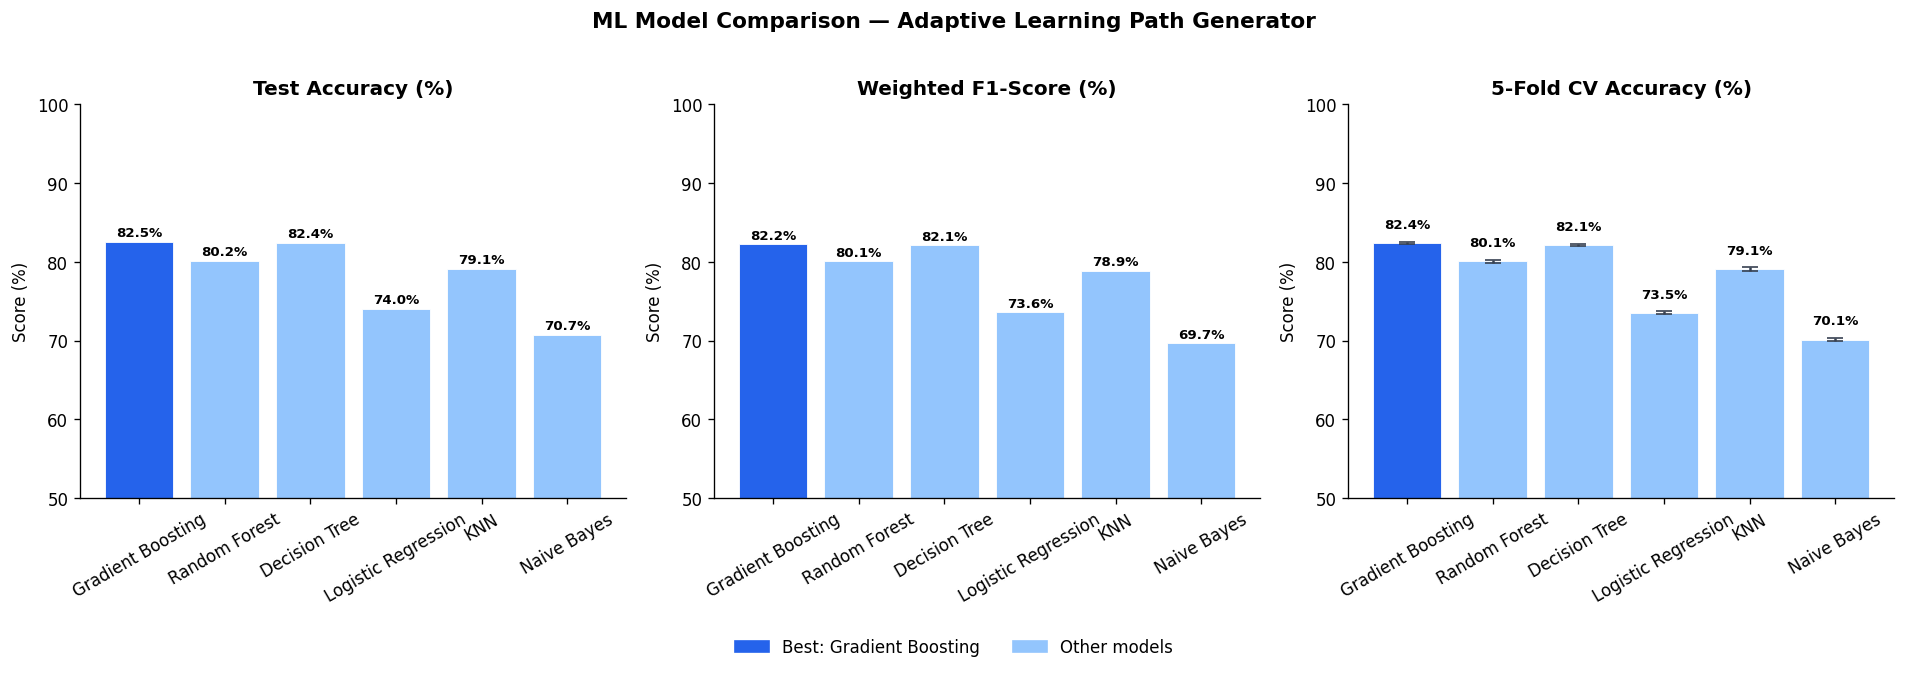

Saved: model_comparison_chart.png


In [11]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] * 100 for m in model_names]
f1_scores   = [results[m]['f1'] * 100 for m in model_names]
cv_means    = [results[m]['cv_mean'] * 100 for m in model_names]
cv_stds     = [results[m]['cv_std'] * 100 for m in model_names]
colors      = ['#2563eb' if m == best_model_name else '#93c5fd' for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('ML Model Comparison — Adaptive Learning Path Generator',
             fontsize=13, fontweight='bold', y=1.02)

for ax, vals, title, yerr in [
    (axes[0], accuracies, 'Test Accuracy (%)',      None),
    (axes[1], f1_scores,  'Weighted F1-Score (%)',  None),
    (axes[2], cv_means,   '5-Fold CV Accuracy (%)', cv_stds),
]:
    kw = dict(color=colors, edgecolor='white', linewidth=0.5)
    if yerr:
        kw['yerr']     = yerr
        kw['capsize']  = 5
        kw['error_kw'] = {'linewidth': 1.5, 'ecolor': '#374151'}
    bars = ax.bar(model_names, vals, **kw)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(50, 100)
    ax.set_ylabel('Score (%)')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (1.5 if yerr else 0.3),
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

best_p  = mpatches.Patch(color='#2563eb', label=f'Best: {best_model_name}')
other_p = mpatches.Patch(color='#93c5fd', label='Other models')
fig.legend(handles=[best_p, other_p], loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.08), frameon=False)

plt.tight_layout()
plt.savefig('model_comparison_chart.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: model_comparison_chart.png")

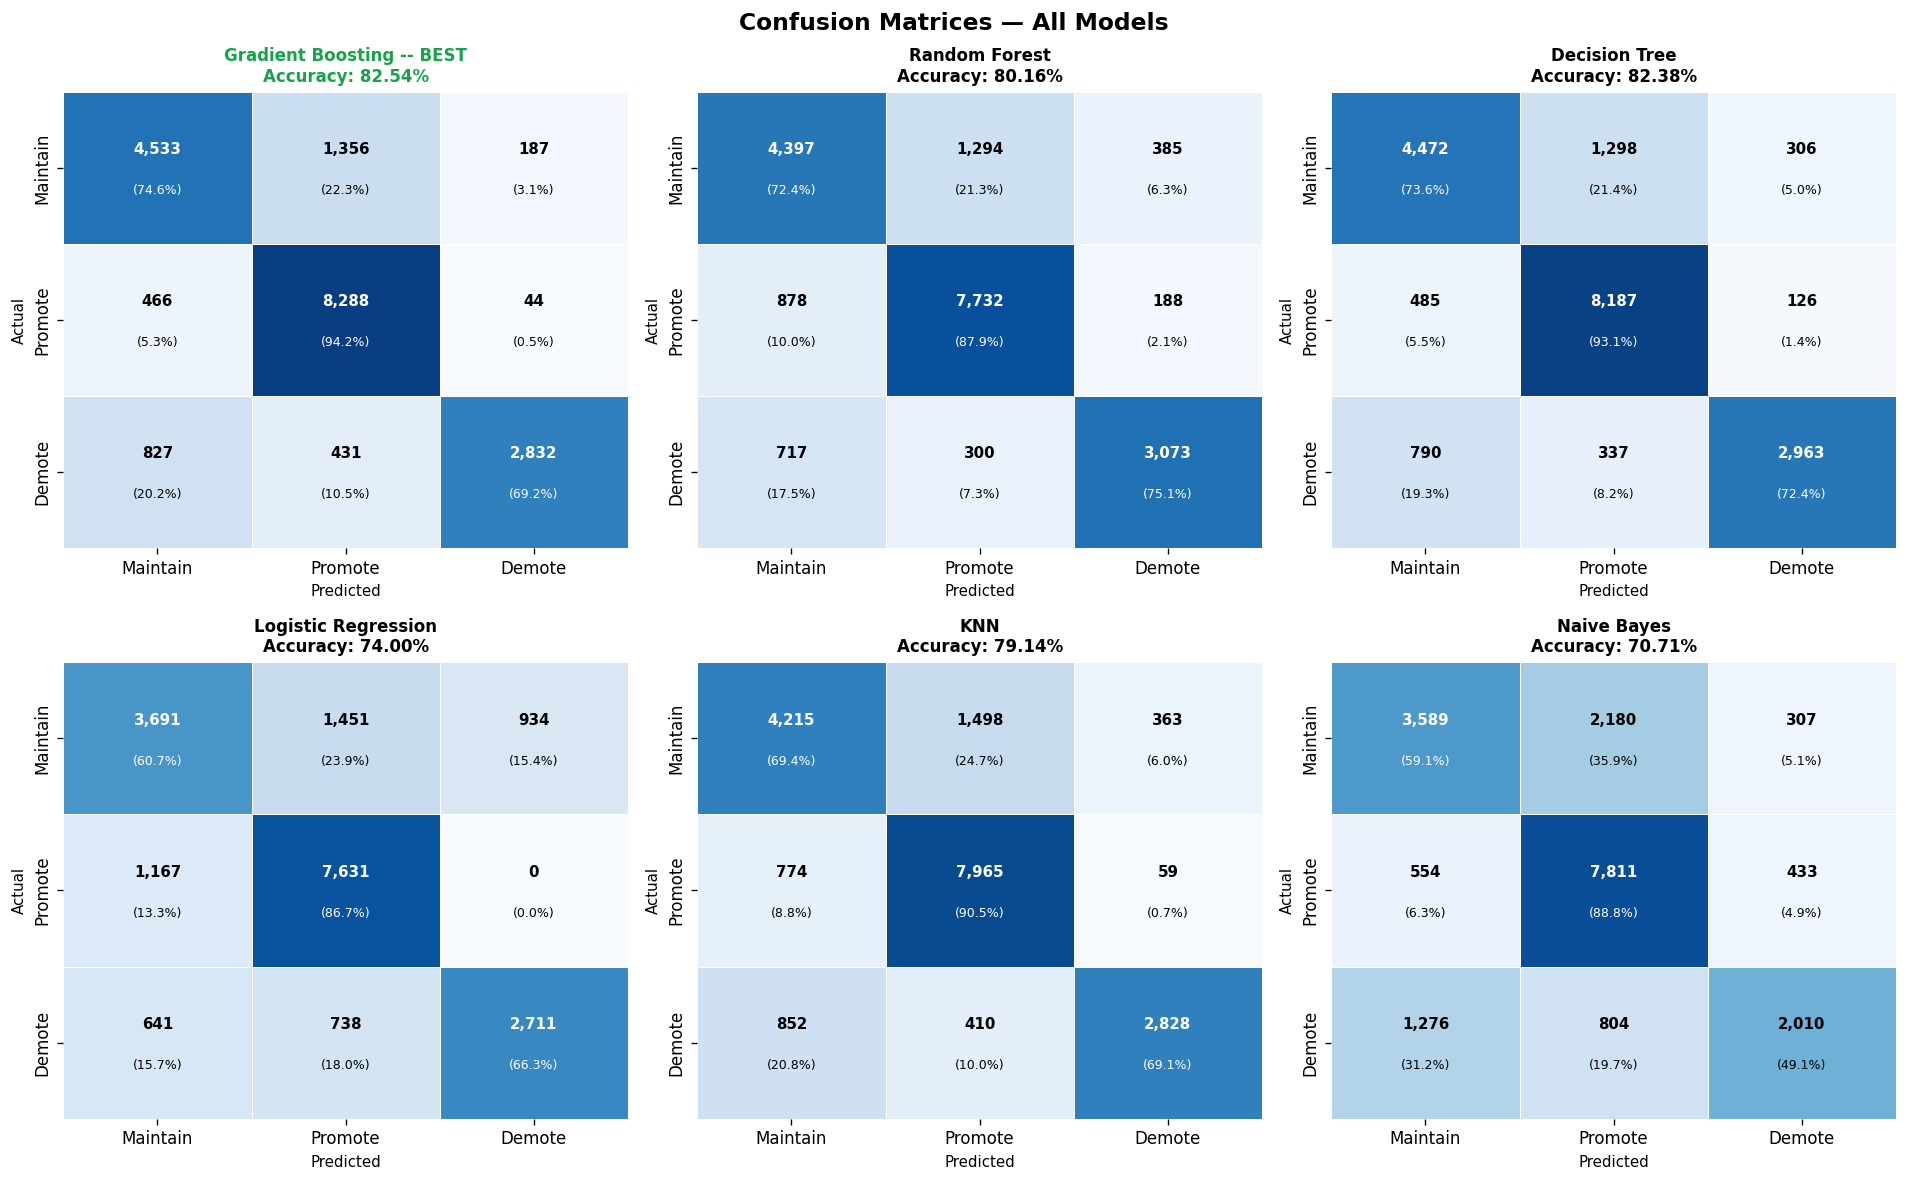

Saved: confusion_matrices.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

for idx, (name, r) in enumerate(results.items()):
    ax     = axes.flatten()[idx]
    cm     = confusion_matrix(y_test, r['y_pred'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm_pct, annot=False, cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS,
                ax=ax, linewidths=0.5, linecolor='white',
                vmin=0, vmax=100, cbar=False)

    for i in range(3):
        for j in range(3):
            count = cm[i, j]
            pct   = cm_pct[i, j]
            color = 'white' if pct > 50 else 'black'
            ax.text(j+0.5, i+0.38, f'{count:,}',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold', color=color)
            ax.text(j+0.5, i+0.65, f'({pct:.1f}%)',
                    ha='center', va='center', fontsize=7.5, color=color)

    star   = ' -- BEST' if name == best_model_name else ''
    tcolor = '#16a34a' if name == best_model_name else 'black'
    ax.set_title(f'{name}{star}\nAccuracy: {r["accuracy"]*100:.2f}%',
                 fontweight='bold', color=tcolor, fontsize=10)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: confusion_matrices.png")

In [13]:
for name, r in results.items():
    star = "  <-- BEST MODEL" if name == best_model_name else ""
    print("=" * 58)
    print(f" {name}{star}")
    print("=" * 58)
    print(classification_report(y_test, r['y_pred'], target_names=LABELS))
    print(f" 5-Fold CV : {r['cv_mean']*100:.2f}% +/- {r['cv_std']*100:.2f}%")
    print()

 Gradient Boosting  <-- BEST MODEL
              precision    recall  f1-score   support

    Maintain       0.78      0.75      0.76      6076
     Promote       0.82      0.94      0.88      8798
      Demote       0.92      0.69      0.79      4090

    accuracy                           0.83     18964
   macro avg       0.84      0.79      0.81     18964
weighted avg       0.83      0.83      0.82     18964

 5-Fold CV : 82.44% +/- 0.12%

 Random Forest
              precision    recall  f1-score   support

    Maintain       0.73      0.72      0.73      6076
     Promote       0.83      0.88      0.85      8798
      Demote       0.84      0.75      0.79      4090

    accuracy                           0.80     18964
   macro avg       0.80      0.78      0.79     18964
weighted avg       0.80      0.80      0.80     18964

 5-Fold CV : 80.06% +/- 0.18%

 Decision Tree
              precision    recall  f1-score   support

    Maintain       0.78      0.74      0.76      6076
  

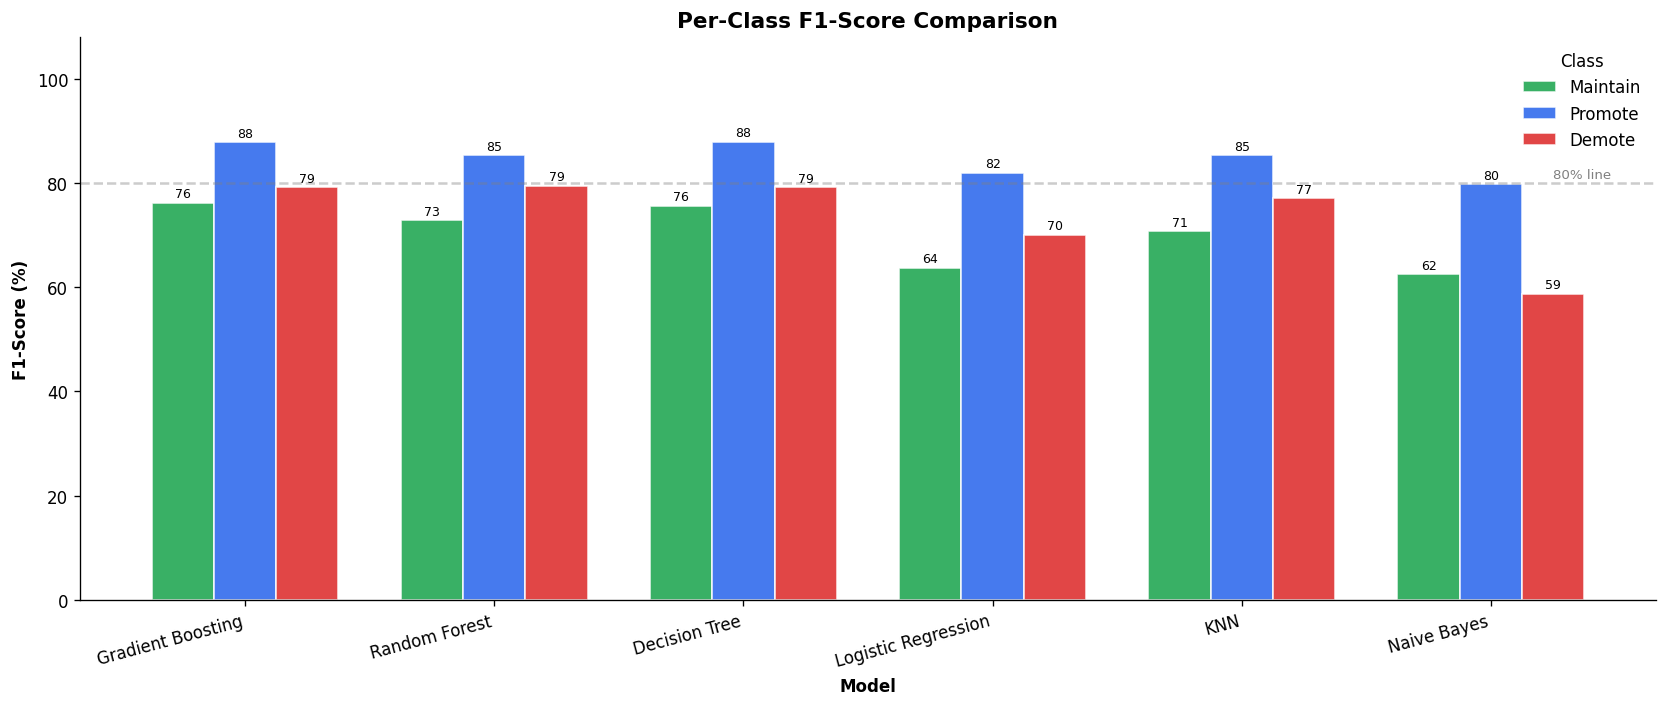

Saved: per_class_f1_comparison.png


In [14]:
class_f1 = {}
for name, r in results.items():
    rpt = classification_report(y_test, r['y_pred'],
                                target_names=LABELS, output_dict=True)
    class_f1[name] = {l: rpt[l]['f1-score'] for l in LABELS}

x    = np.arange(len(model_names))
w    = 0.25
clrs = ['#16a34a', '#2563eb', '#dc2626']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (label, color) in enumerate(zip(LABELS, clrs)):
    vals = [class_f1[m][label] * 100 for m in model_names]
    bars = ax.bar(x + i*w, vals, w, label=label,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('F1-Score (%)', fontweight='bold')
ax.set_title('Per-Class F1-Score Comparison', fontweight='bold', fontsize=13)
ax.set_xticks(x + w)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 108)
ax.legend(title='Class', frameon=False)
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.4)
ax.text(len(model_names)-0.5, 81, '80% line', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('per_class_f1_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: per_class_f1_comparison.png")

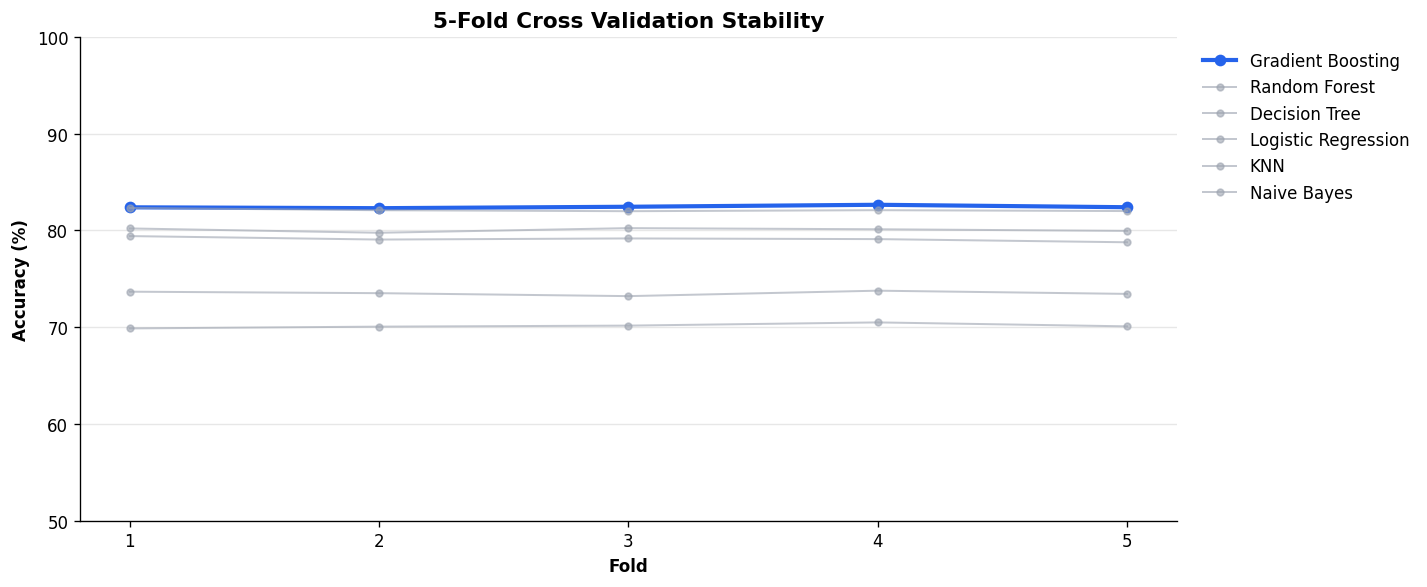

Saved: cv_stability_chart.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

for name, r in results.items():
    is_best = name == best_model_name
    ax.plot(np.arange(1, 6), r['cv_scores'] * 100,
            marker='o', label=name,
            color='#2563eb' if is_best else '#9ca3af',
            linewidth=2.5 if is_best else 1.2,
            alpha=1.0 if is_best else 0.6,
            markersize=6 if is_best else 4)

ax.set_xlabel('Fold', fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('5-Fold Cross Validation Stability', fontweight='bold', fontsize=13)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(50, 100)
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cv_stability_chart.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: cv_stability_chart.png")

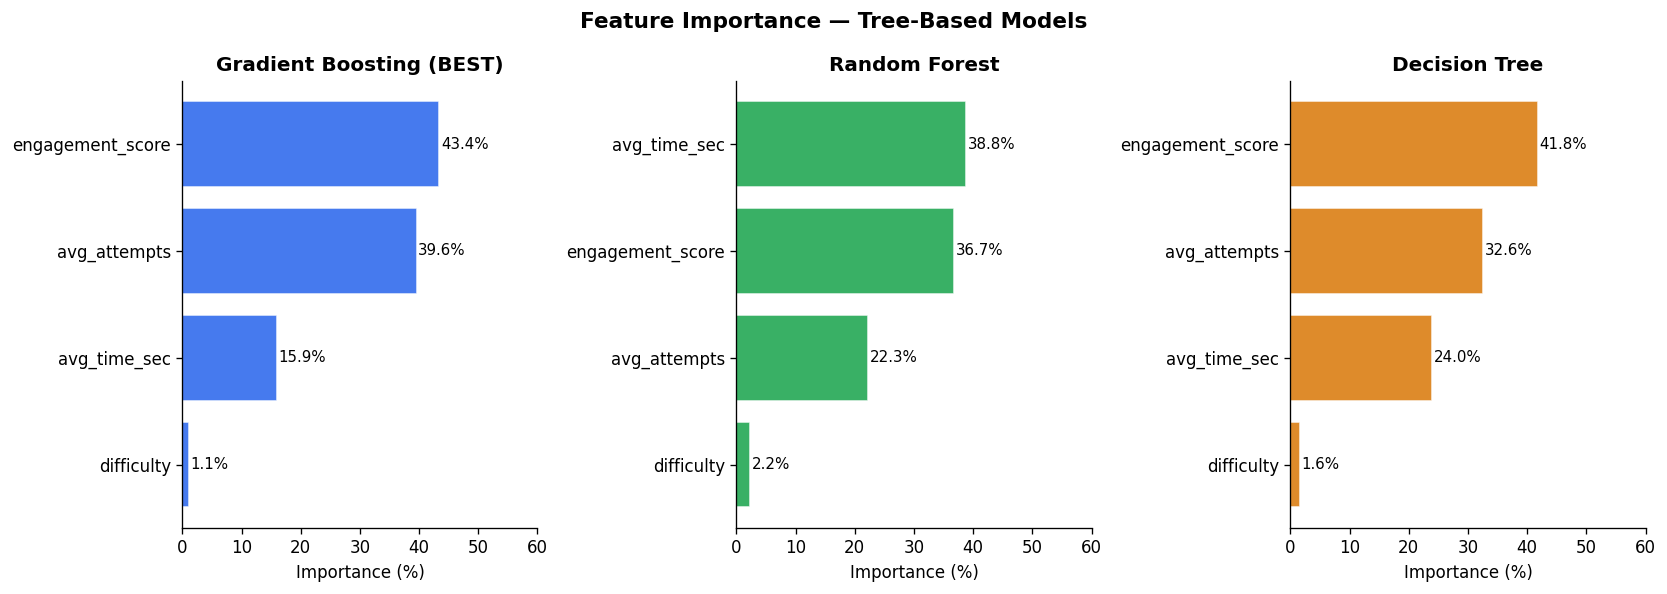

Saved: feature_importance.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Feature Importance — Tree-Based Models',
             fontweight='bold', fontsize=13)

for ax, name, color in zip(axes,
    ['Gradient Boosting', 'Random Forest', 'Decision Tree'],
    ['#2563eb', '#16a34a', '#d97706']):
    fi   = pd.Series(results[name]['model'].feature_importances_,
                     index=FEATURES).sort_values()
    bars = ax.barh(fi.index, fi.values * 100,
                   color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, fi.values * 100):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    star = ' (BEST)' if name == best_model_name else ''
    ax.set_title(f'{name}{star}', fontweight='bold')
    ax.set_xlabel('Importance (%)')
    ax.set_xlim(0, 60)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: feature_importance.png")

In [17]:
import joblib, os

print("=" * 60)
print(" FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Rank':<6}{'Model':<22}{'Accuracy':>10}{'F1':>8}{'CV Mean':>10}{'CV Std':>10}")
print("-" * 60)

for rank, (name, r) in enumerate(
    sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True), 1
):
    star = "  <-- BEST" if rank == 1 else ""
    print(f"{rank:<6}{name:<22}"
          f"{r['accuracy']*100:>9.2f}%"
          f"{r['f1']*100:>7.2f}%"
          f"{r['cv_mean']*100:>9.2f}%"
          f"  +-{r['cv_std']*100:.2f}%{star}")

print()
print(f"Selected model : {best_model_name}")
print(f"Test accuracy  : {results[best_model_name]['accuracy']*100:.2f}%")
print(f"5-Fold CV      : {results[best_model_name]['cv_mean']*100:.2f}% +/- {results[best_model_name]['cv_std']*100:.2f}%")

# Save best model
joblib.dump(results[best_model_name]['model'], os.path.join('ml', 'model.pkl'))
print()
print("Best model saved -> ml/model.pkl")
print()
print("All files saved:")
for f in ['model_comparison_chart.png', 'confusion_matrices.png',
          'per_class_f1_comparison.png', 'cv_stability_chart.png',
          'feature_importance.png']:
    print(f"  {f}")

 FINAL MODEL COMPARISON SUMMARY
Rank  Model                   Accuracy      F1   CV Mean    CV Std
------------------------------------------------------------
1     Gradient Boosting         82.54%  82.23%    82.44%  +-0.12%  <-- BEST
2     Decision Tree             82.38%  82.11%    82.10%  +-0.12%
3     Random Forest             80.16%  80.07%    80.06%  +-0.18%
4     KNN                       79.14%  78.87%    79.11%  +-0.21%
5     Logistic Regression       74.00%  73.58%    73.52%  +-0.19%
6     Naive Bayes               70.71%  69.67%    70.14%  +-0.20%

Selected model : Gradient Boosting
Test accuracy  : 82.54%
5-Fold CV      : 82.44% +/- 0.12%

Best model saved -> ml/model.pkl

All files saved:
  model_comparison_chart.png
  confusion_matrices.png
  per_class_f1_comparison.png
  cv_stability_chart.png
  feature_importance.png
